Step 1: Import relevent libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Step 2: Load Dataset

In [57]:
data = pd.read_csv('Housing.csv')

Step 3: View Dataset

In [58]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


Step 4: Data Exploration

In [59]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


Step 5: Fix any skews and convert columns to numerics

In [ ]:
# Convert yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

# Encode furnishingstatus (3 categories)
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

# Transform skewed columns in log figures
data['price_log'] = np.log(data['price'])
data['area_log'] = np.log(data['area'])

Step 6: Train Model

In [61]:
from sklearn.model_selection import train_test_split

x = data.drop(['price', 'price_log'], axis=1)
y = data['price_log']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
train_data = x_train.join(y_train)
train_data

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_log,price_log
46,6000,3,2,4,1,0,0,0,1,1,0,False,False,8.699515,15.833741
93,7200,3,2,1,1,0,1,0,1,3,0,True,False,8.881836,15.656060
335,3816,2,1,1,1,0,1,0,1,2,0,False,False,8.246958,15.181602
412,2610,3,1,2,1,0,1,0,0,0,1,False,True,7.867106,15.048071
471,3750,3,1,2,1,0,0,0,0,0,0,False,True,8.229511,14.917451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,False,True,8.699515,15.725794
106,5450,4,2,1,1,0,1,0,1,0,1,True,False,8.603371,15.633587
270,4500,3,2,3,1,0,0,1,0,1,0,False,False,8.411833,15.283385
435,4040,2,1,1,1,0,0,0,0,0,0,False,True,8.304000,15.006398


Step 7: Show distribution

array([[<Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'stories'}>],
       [<Axes: title={'center': 'mainroad'}>,
        <Axes: title={'center': 'guestroom'}>,
        <Axes: title={'center': 'basement'}>,
        <Axes: title={'center': 'hotwaterheating'}>],
       [<Axes: title={'center': 'airconditioning'}>,
        <Axes: title={'center': 'parking'}>,
        <Axes: title={'center': 'prefarea'}>,
        <Axes: title={'center': 'area_log'}>],
       [<Axes: title={'center': 'price_log'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

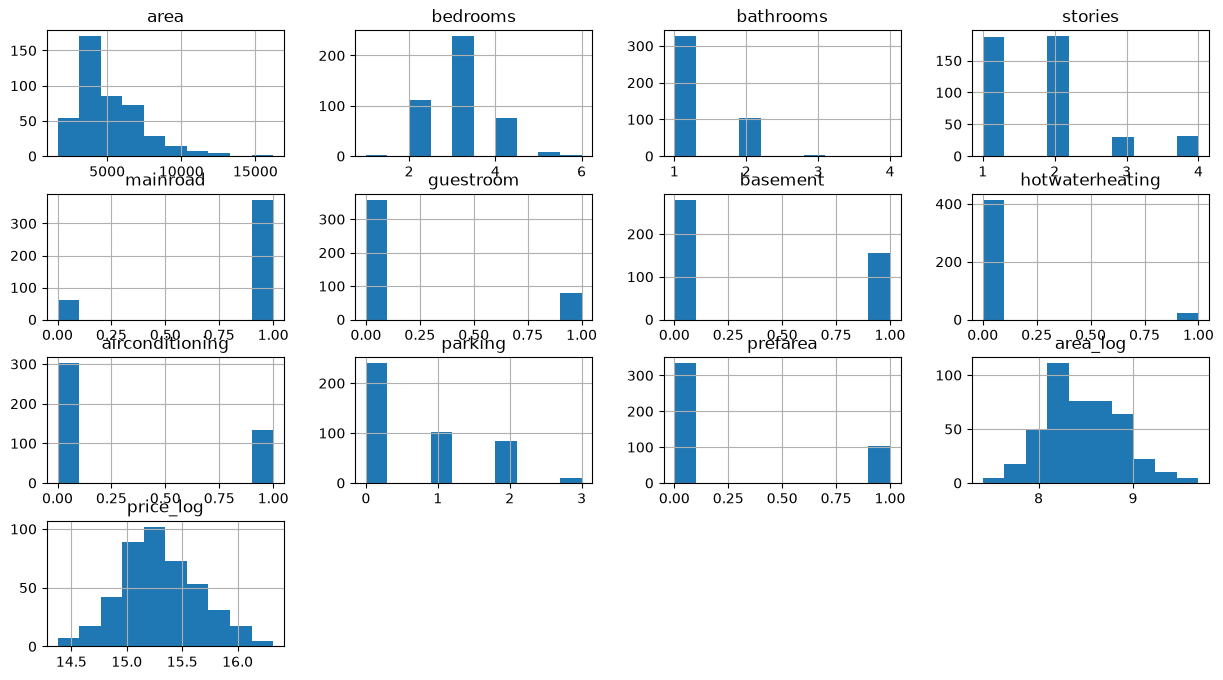

In [63]:
train_data.hist(figsize=(15, 8))

Step 8: Find any correlations

<Axes: >

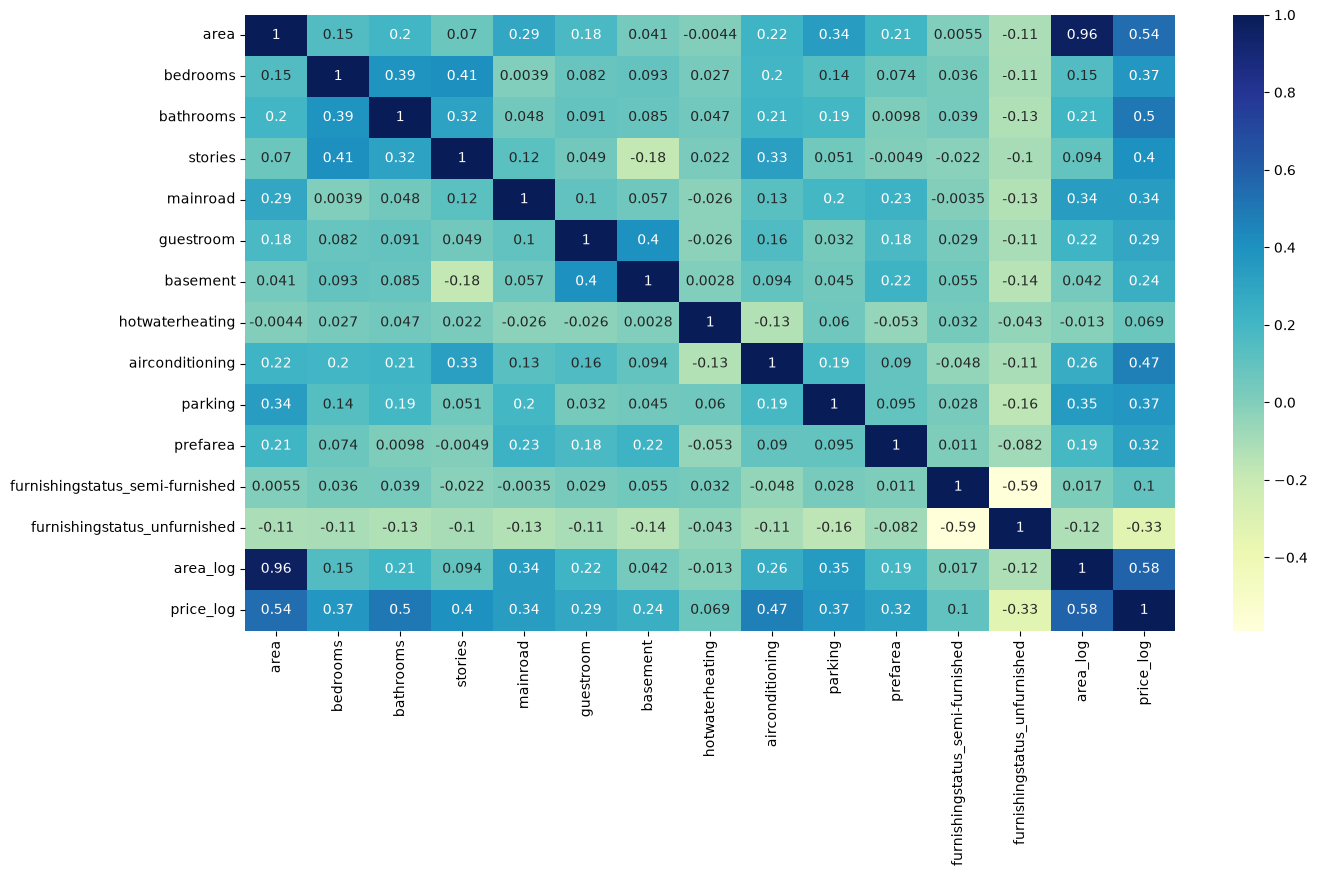

In [64]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

Step 9: Scale the features

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Step 10: Train Model with linear regression

In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0.04, 0.02, 0.09,...,-0. ,-0.05, 0.16]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](14,)","[36.14,26.79,26.48,...,13.37,12.53, 3.74]"


Step 11: Predict with both log and raw price

In [67]:
y_pred_log = model.predict(x_test_scaled)

y_pred_actual = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

Step 12: Evaluate the model

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))
print("R^2:", r2_score(y_test_actual, y_pred_actual))

MAE: 972812.6738990397
RMSE: 1317370.5771871242
R^2: 0.6566542449601511


Step 13: Interpret findings

In [69]:
print("Average price:", data['price'].mean())

Average price: 4766729.247706422


The model has an R^2 of approximately 0.66, meaning it explains about 66% of the variation in house prices based on the current features. The MAE of 972,812 represents about 20% of the average house price which is about 4,766,729, indicating the model's predictions are reasonably close but not highly precise. The gap between RMSE and MAE suggests a subset of predictions have some larger errors, pulling the RMSE up. Overall, this represents a solid baseline performance for Linear Regression, with room for improvement — likely through additional features or a model capable of using non-linear relationships.

Step 14: Interpret coefficients

In [70]:
coefficients = pd.DataFrame({'feature': x.columns, 'coefficient': model.coef_}).sort_values('coefficient', key=abs, ascending=False)

print(coefficients)

                            feature  coefficient
13                         area_log     0.158362
2                         bathrooms     0.088345
3                           stories     0.070424
8                   airconditioning     0.065773
10                         prefarea     0.058071
12     furnishingstatus_unfurnished    -0.054268
6                          basement     0.050225
0                              area    -0.041231
4                          mainroad     0.029202
7                   hotwaterheating     0.029020
9                           parking     0.028261
1                          bedrooms     0.015625
5                         guestroom     0.012182
11  furnishingstatus_semi-furnished    -0.003634


The coefficients show that area_log is the strongest positive driver of price, followed by bathrooms, stories and airconditioning which make sense as predictors of house value. Being in a preferred area and having a basement also contribute positively. Unfurnished homes are associated with lower prices relative to furnished homes which again also makes sense. Note that both area and area_log were included as features, which introduces multicollinearity since they represent the same information this likely explains why their coefficients point in opposite directions despite both stemming from the same variable.

Step 15: Save the model

In [71]:
import joblib

joblib.dump(model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Step 16: Example Predictions

In [73]:
# Take rows from the test set
sample = x_test.iloc[:10]
sample_scaled = scaler.transform(sample)

predicted_log = model.predict(sample_scaled)
predicted_price = np.exp(predicted_log)
actual_price = np.exp(y_test.iloc[:10])

In [74]:
comparison = pd.DataFrame({'Actual Price': actual_price.values, 'Predicted Price': predicted_price})

comparison['Predicted Price'] = comparison['Predicted Price'].round(0)
print(comparison)

   Actual Price  Predicted Price
0     4060000.0        4826034.0
1     6650000.0        7425975.0
2     3710000.0        3333632.0
3     6440000.0        4556851.0
4     2800000.0        3407059.0
5     4900000.0        3553342.0
6     5250000.0        5229684.0
7     4543000.0        6428419.0
8     2450000.0        2726046.0
9     3353000.0        2754660.0


Conclusion

This project built a baseline Linear Regression model to predict house prices using the Housing dataset sourced from kaggle. After cleaning the data the model was trained on an 80/20 train-test split.

The model achieved an R^2 of approximately 0.66, meaning it explains about 66% of the variation in house prices, with an MAE of roughly 972,812 which is about about 20% of the average house price. Example predictions on the test set showed the model generally landing within a reasonable range of actual prices, though with some individual predictions off by 20–30%, particularly for higher-priced properties.

Coefficient analysis revealed that area_log, bathrooms, stories and airconditioning were the strongest positive drivers of price, while unfurnished homes were associated with lower prices compared to furnished ones. This aligns with real-world expectations about what drives a house's value.

Overall, the model provides a solid, interpretable baseline for house price prediction. Its main drawback is that the Linear Regression model can only capture linear relationships between features and price and the dataset does not include other influential factors such as exact location, neighborhood quality and/or property age. Future improvement could come from engineering additional features, addressing multicollinearity between area and area_log or trying models capable of capturing non-linear relationships like Random Forest or Gradient Boosting should the task scope call for it.

The final model and scaler were saved using joblib for potential reuse in future predictions.